In [1]:
import re
import pandas as pd

# Original uncleaned paragraphs from the assignment
paragraphs = [
    """OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!! 
    It was soooo gooood lol. I <3 nlp butttt i hate spelng errors in textttt. 
    This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
    The website's link is www.example.com//// Check it out ASAP!!! #excited""",

    """Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web. 
    This article, "The Marvels of Artificial General Intelligence & the Future of Humanity," 
    totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. 
    I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. 
    Brace yourselves, this is gonna be one seriously long paragraph with tons and tons of 
    extraterrestrial spaces and some seriously weird symbols like @#$%. 
    And guess what? The link to the website is www.incrediblenews.com//// 
    So, um, you better check it out like ASAP!!! #excitedmuch""",

    """yaaayyyy!!! just watched thisssss AMAZZZING vid on AI & how it's changin' 
    evrythinggg!! it waz soooo dopeee, i can’t even... lolzzz! #blessed #mindblownn... 
    btw, the link is http://coolai.stuff.com//// totally worthhh ittttttt @@@!!! 
    i <3 tech so much but sometimes it's likee realllyyy confusingggg!!!""",

    """nooo waayyyyy!!!! this is, like, the 1000000th time i've seen ppl mess up spellings 
    in their blogsssss i mean c'mon, u're writing abt deep learning, not sum joke topic 
    anywayzzzz... the article was kinda cooool butttt had lotsa weird $$$%%%@@ symbols all 
    over. you can read it @ www.badblogger.ai//// and let me knw ur thots ASAP!!!""",

    """heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? 
    like for realll... it wuz crazzzzy detailed but sooooo complicateddd!!! 
    i cud barely undrstnd half of it. the diagrams were fire though!!! 
    i found it here – www.quantmgeekzz.net//// … plz plz plz read n 
    tell me what u thinkk #toomuchinfo #brainhurts @@@!!!"""
]

print("Number of paragraphs:", len(paragraphs))

for i, paragraph in enumerate(paragraphs, 1):
    print(f"\nParagraph {i}:")
    print(paragraph)

Number of paragraphs: 5

Paragraph 1:
OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!! 
    It was soooo gooood lol. I <3 nlp butttt i hate spelng errors in textttt. 
    This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. 
    The website's link is www.example.com//// Check it out ASAP!!! #excited

Paragraph 2:
Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web. 
    This article, "The Marvels of Artificial General Intelligence & the Future of Humanity," 
    totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. 
    I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. 
    Brace yourselves, this is gonna be one seriously long paragraph with tons and tons of 
    extraterrestrial spaces and some seriously weird symbols like @#$%. 
    And guess what? The link to the website is www.incrediblenews.com//// 
    So, um, you better check it out li

In [4]:
def clean_text(text):

    # 1. Lowercasing
    text = text.lower()

    # 2. Handling contractions and common text expressions
    contractions = {
        "can't": "cannot",
        "i'm": "i am",
        "i've": "i have",
        "it's": "it is",
        "i'll": "i will",
        "i'd": "i would",
        "you're": "you are",
        "u're": "you are",
        "waz": "was",
        "wuz": "was",
        "c'mon": "come on",
        "i <3": "i love",
        "<3": "love"
    }

    for old, new in contractions.items():
        text = text.replace(old, new)

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Remove URL artifacts and special characters
    text = re.sub(r'[@#$%&*]', ' ', text)

    # 5. Normalize common spelling/text errors
    corrections = {
        "aWesoMe": "awesome",
        "leanring": "learning",
        "gooood": "good",
        "spelng": "spelling",
        "textttt": "text",
        "looong": "long",
        "looooots": "lots",
        "spacesss": "spaces",
        "weirddddd": "weird",
        "mindddd": "mind",
        "lolz": "lol",
        "butttt": "but",
        "yaaayyyy": "yay",
        "thisssss": "this",
        "amazzzing": "amazing",
        "changin": "changing",
        "evrythinggg": "everything",
        "dopeee": "dope",
        "lolzzz": "lol",
        "mindblownn": "mindblown",
        "worthhh": "worth",
        "ittttt": "it",
        "likee": "like",
        "realllyyy": "really",
        "confusingggg": "confusing",
        "nooo": "no",
        "waayyyyy": "way",
        "blogsssss": "blogs",
        "anywayzzzz": "anyway",
        "cooool": "cool",
        "lotsa": "lots of",
        "knw": "know",
        "thots": "thoughts",
        "heyyyyy": "hey",
        "crazyyyyyyy": "crazy",
        "realll": "real",
        "crazzzzy": "crazy",
        "complicateddd": "complicated",
        "undrstnd": "understand",
        "plz": "please",
        "thinkk": "think",
        "toomuchinfo": "too much info"
    }

    for old, new in corrections.items():
        text = text.replace(old.lower(), new)

    # 6. Reduce duplicate letters
    # More than 2 consecutive copies -> maximum of 2
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. Remove remaining special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
cleaned_paragraphs = []

for paragraph in paragraphs:
    cleaned = clean_text(paragraph)
    cleaned_paragraphs.append(cleaned)

for i, cleaned in enumerate(cleaned_paragraphs, 1):
    print(f"\n{'=' * 70}")
    print(f"Cleaned Paragraph {i}")
    print('=' * 70)
    print(cleaned)


Cleaned Paragraph 1
omg i cannot believe i found this awesome article about ai machine learning it was soo good lol i love nlp but i hate spelling errors in text this is gonna be a long paragraph with lots of spaces and weird symbols the website s link is check it out asap excited

Cleaned Paragraph 2
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mind it was like soo mind blowingly awesome lol i mean i love nlp but those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excitedmuch

Cleaned Paragraph 3
yay just watched this amazing vid on ai how it is changing everything it was soo dope i can t even lolzz blessed mindblown btw the link

In [6]:
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer data
nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenize all cleaned paragraphs
tokenized_paragraphs = []

for paragraph in cleaned_paragraphs:
    tokens = word_tokenize(paragraph)
    tokenized_paragraphs.append(tokens)

# Display tokens
for i, tokens in enumerate(tokenized_paragraphs, 1):
    print(f"\n{'=' * 60}")
    print(f"Tokenized Paragraph {i}")
    print('=' * 60)
    print(tokens)
    print("Number of tokens:", len(tokens))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mahat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.



Tokenized Paragraph 1
['omg', 'i', 'can', 'not', 'believe', 'i', 'found', 'this', 'awesome', 'article', 'about', 'ai', 'machine', 'learning', 'it', 'was', 'soo', 'good', 'lol', 'i', 'love', 'nlp', 'but', 'i', 'hate', 'spelling', 'errors', 'in', 'text', 'this', 'is', 'gon', 'na', 'be', 'a', 'long', 'paragraph', 'with', 'lots', 'of', 'spaces', 'and', 'weird', 'symbols', 'the', 'website', 's', 'link', 'is', 'check', 'it', 'out', 'asap', 'excited']
Number of tokens: 54

Tokenized Paragraph 2
['oh', 'my', 'gosh', 'like', 'i', 'can', 'not', 'even', 'believe', 'what', 'i', 'just', 'stumbled', 'upon', 'on', 'the', 'world', 'wide', 'web', 'this', 'article', 'the', 'marvels', 'of', 'artificial', 'general', 'intelligence', 'the', 'future', 'of', 'humanity', 'totally', 'blew', 'my', 'mind', 'it', 'was', 'like', 'soo', 'mind', 'blowingly', 'awesome', 'lol', 'i', 'mean', 'i', 'love', 'nlp', 'but', 'those', 'annoying', 'typos', 'in', 'texts', 'drive', 'me', 'nuts', 'brace', 'yourselves', 'this', 'is

Top 20 Most Frequent Words:
i: 14
it: 11
the: 10
is: 8
like: 7
this: 6
of: 6
was: 5
but: 5
and: 5
can: 4
article: 4
soo: 4
on: 4
not: 3
ai: 3
love: 3
in: 3
weird: 3
symbols: 3


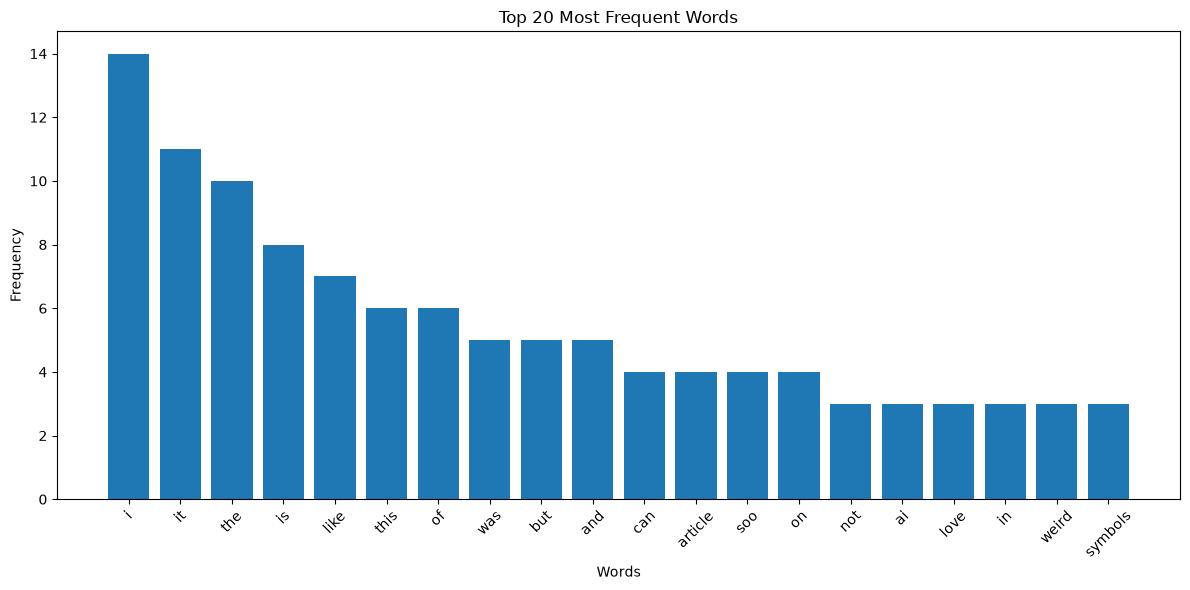

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

# Combine all tokens from the 5 paragraphs
all_tokens = []

for tokens in tokenized_paragraphs:
    all_tokens.extend(tokens)

# Count frequency of each word
word_frequency = Counter(all_tokens)

# Display the 20 most frequent words
top_20 = word_frequency.most_common(20)

print("Top 20 Most Frequent Words:")
for word, count in top_20:
    print(f"{word}: {count}")

# Prepare data for bar chart
words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from nltk.stem import PorterStemmer

# Create Porter Stemmer
stemmer = PorterStemmer()

# Apply stemming to all tokens
stemmed_paragraphs = []

for tokens in tokenized_paragraphs:
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    stemmed_paragraphs.append(stemmed_tokens)

# Display stemmed results
for i, stems in enumerate(stemmed_paragraphs, 1):
    print(f"\n{'=' * 60}")
    print(f"Porter Stemmed Paragraph {i}")
    print('=' * 60)
    print(stems)


Porter Stemmed Paragraph 1
['omg', 'i', 'can', 'not', 'believ', 'i', 'found', 'thi', 'awesom', 'articl', 'about', 'ai', 'machin', 'learn', 'it', 'wa', 'soo', 'good', 'lol', 'i', 'love', 'nlp', 'but', 'i', 'hate', 'spell', 'error', 'in', 'text', 'thi', 'is', 'gon', 'na', 'be', 'a', 'long', 'paragraph', 'with', 'lot', 'of', 'space', 'and', 'weird', 'symbol', 'the', 'websit', 's', 'link', 'is', 'check', 'it', 'out', 'asap', 'excit']

Porter Stemmed Paragraph 2
['oh', 'my', 'gosh', 'like', 'i', 'can', 'not', 'even', 'believ', 'what', 'i', 'just', 'stumbl', 'upon', 'on', 'the', 'world', 'wide', 'web', 'thi', 'articl', 'the', 'marvel', 'of', 'artifici', 'gener', 'intellig', 'the', 'futur', 'of', 'human', 'total', 'blew', 'my', 'mind', 'it', 'wa', 'like', 'soo', 'mind', 'blowingli', 'awesom', 'lol', 'i', 'mean', 'i', 'love', 'nlp', 'but', 'those', 'annoy', 'typo', 'in', 'text', 'drive', 'me', 'nut', 'brace', 'yourselv', 'thi', 'is', 'gon', 'na', 'be', 'one', 'serious', 'long', 'paragraph', '

In [9]:
from nltk.stem import WordNetLemmatizer
import nltk

# Download WordNet resources
nltk.download('wordnet')
nltk.download('omw-1.4')

# Create lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
lemmatized_paragraphs = []

for tokens in tokenized_paragraphs:
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    lemmatized_paragraphs.append(lemmatized_tokens)

# Display lemmatized results
for i, lemmas in enumerate(lemmatized_paragraphs, 1):
    print(f"\n{'=' * 60}")
    print(f"WordNet Lemmatized Paragraph {i}")
    print('=' * 60)
    print(lemmas)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mahat\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mahat\AppData\Roaming\nltk_data...



WordNet Lemmatized Paragraph 1
['omg', 'i', 'can', 'not', 'believe', 'i', 'found', 'this', 'awesome', 'article', 'about', 'ai', 'machine', 'learning', 'it', 'wa', 'soo', 'good', 'lol', 'i', 'love', 'nlp', 'but', 'i', 'hate', 'spelling', 'error', 'in', 'text', 'this', 'is', 'gon', 'na', 'be', 'a', 'long', 'paragraph', 'with', 'lot', 'of', 'space', 'and', 'weird', 'symbol', 'the', 'website', 's', 'link', 'is', 'check', 'it', 'out', 'asap', 'excited']

WordNet Lemmatized Paragraph 2
['oh', 'my', 'gosh', 'like', 'i', 'can', 'not', 'even', 'believe', 'what', 'i', 'just', 'stumbled', 'upon', 'on', 'the', 'world', 'wide', 'web', 'this', 'article', 'the', 'marvel', 'of', 'artificial', 'general', 'intelligence', 'the', 'future', 'of', 'humanity', 'totally', 'blew', 'my', 'mind', 'it', 'wa', 'like', 'soo', 'mind', 'blowingly', 'awesome', 'lol', 'i', 'mean', 'i', 'love', 'nlp', 'but', 'those', 'annoying', 'typo', 'in', 'text', 'drive', 'me', 'nut', 'brace', 'yourselves', 'this', 'is', 'gon', 'na

In [10]:
# Compare Porter Stemming and WordNet Lemmatization
comparison_words = [
    "learning",
    "articles",
    "changing",
    "amazing",
    "spelling",
    "watched",
    "stumbled",
    "blogs",
    "symbols",
    "crazy",
    "detailed",
    "spaces",
    "weird",
    "complicated",
    "thoughts"
]

comparison_data = []

for word in comparison_words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)

    comparison_data.append({
        "Original Word": word,
        "Porter Stem": stemmed,
        "WordNet Lemma": lemmatized
    })

comparison_df = pd.DataFrame(comparison_data)

print("Stemming vs Lemmatization Comparison:")
display(comparison_df)

Stemming vs Lemmatization Comparison:


,Original Word,Porter Stem,WordNet Lemma
0,learning,learn,learning
1,articles,articl,article
2,changing,chang,changing
3,amazing,amaz,amazing
4,spelling,spell,spelling
5,watched,watch,watched
6,stumbled,stumbl,stumbled
7,blogs,blog,blog
8,symbols,symbol,symbol
9,crazy,crazi,crazy


In [13]:
# Named Entity Recognition (NER)

import spacy

# Load English language model
nlp = spacy.load("en_core_web_sm")

# Combine the cleaned paragraphs
text_for_ner = " ".join(cleaned_paragraphs)

# Process the text
doc = nlp(text_for_ner)

# Display named entities
print("Named Entities:")
print("=" * 60)

for ent in doc.ents:
    print(f"Entity: {ent.text} | Label: {ent.label_} | Description: {spacy.explain(ent.label_)}")

Named Entities:
Entity: 100th | Label: ORDINAL | Description: "first", "second", etc.
Entity: half | Label: CARDINAL | Description: Numerals that do not fall under another type
Entity: info brainhurts | Label: PERSON | Description: People, including fictional


In [15]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mahat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [16]:
# Part-of-Speech (POS) Tagging

import nltk
from nltk import word_tokenize, pos_tag

# POS tagging for each cleaned paragraph
for i, paragraph in enumerate(cleaned_paragraphs, 1):
    tokens = word_tokenize(paragraph)
    tagged_words = pos_tag(tokens)

    print("=" * 60)
    print(f"POS Tagged Paragraph {i}")
    print("=" * 60)
    print(tagged_words)

POS Tagged Paragraph 1
[('omg', 'IN'), ('i', 'NNS'), ('can', 'MD'), ('not', 'RB'), ('believe', 'VB'), ('i', 'NN'), ('found', 'VBD'), ('this', 'DT'), ('awesome', 'JJ'), ('article', 'NN'), ('about', 'IN'), ('ai', 'JJ'), ('machine', 'NN'), ('learning', 'VBG'), ('it', 'PRP'), ('was', 'VBD'), ('soo', 'RB'), ('good', 'JJ'), ('lol', 'NN'), ('i', 'NN'), ('love', 'VBP'), ('nlp', 'NN'), ('but', 'CC'), ('i', 'JJ'), ('hate', 'VBP'), ('spelling', 'VBG'), ('errors', 'NNS'), ('in', 'IN'), ('text', 'NN'), ('this', 'DT'), ('is', 'VBZ'), ('gon', 'VBG'), ('na', 'RB'), ('be', 'VB'), ('a', 'DT'), ('long', 'JJ'), ('paragraph', 'NN'), ('with', 'IN'), ('lots', 'NNS'), ('of', 'IN'), ('spaces', 'NNS'), ('and', 'CC'), ('weird', 'JJ'), ('symbols', 'NNS'), ('the', 'DT'), ('website', 'JJ'), ('s', 'NN'), ('link', 'NN'), ('is', 'VBZ'), ('check', 'VB'), ('it', 'PRP'), ('out', 'RP'), ('asap', 'RB'), ('excited', 'JJ')]
POS Tagged Paragraph 2
[('oh', 'UH'), ('my', 'PRP$'), ('gosh', 'NN'), ('like', 'IN'), ('i', 'NN'), ('c

In [17]:
# TF-IDF Analysis

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

# Transform the cleaned paragraphs
tfidf_matrix = vectorizer.fit_transform(cleaned_paragraphs)

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

print("TF-IDF Matrix:")
display(tfidf_df)

print("\nTF-IDF Matrix Shape:", tfidf_df.shape)

TF-IDF Matrix:


,100th,about,abt,ai,all,amazing,and,annoying,anyway,are,...,were,what,wide,with,world,worth,writing,yay,you,yourselves
0,0.000000,0.186551,0.000000,0.124936,0.000000,0.000000,0.124936,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.150508,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.213855,0.106441,0.000000,0.000000,...,0.00000,0.171752,0.106441,0.085876,0.106441,0.000000,0.000000,0.000000,0.085876,0.106441
2,0.000000,0.000000,0.000000,0.122065,0.000000,0.182265,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.182265,0.000000,0.182265,0.000000,0.000000
3,0.152422,0.000000,0.152422,0.000000,0.152422,0.000000,0.102079,0.000000,0.152422,0.152422,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.152422,0.000000,0.245946,0.000000
4,0.000000,0.000000,0.000000,0.098997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.14782,0.119260,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



TF-IDF Matrix Shape: (5, 165)
